Ten skrypt implementuje iteracyjne generowanie i ulepszanie obrazów za pomocą DALL-E. Klasa DalleCreator koordynuje współpracę między agentem generującym obrazy a agentem krytykiem, który ocenia jakość i sugeruje ulepszenia promptów.

# Setup

In [1]:
!pip install -q autogen matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 787.5/787.5 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.5 MB/s eta 0:00:00


Ten kod to polecenie dla interpretera Pythona, które uruchamia instalację dwóch pakietów: `autogen` i `matplotlib`.

*   `!pip` jest komendą, która wywołuje menedżera pakietów pip (Package Installer for Python). Pip służy do pobierania i instalowania dodatkowych bibliotek oraz narzędzi rozszerzających funkcjonalność Pythona. Wykrzyknik `!` na początku w środowiskach takich jak Jupyter Notebook lub Google Colab pozwala na uruchomienie poleceń systemowych bezpośrednio z komórki kodu.

*   `install` to argument przekazywany do pip, który instruuje go o rozpoczęciu procesu instalacji.

*   `-q` (lub `--quiet`) jest opcją, która tłumi większość komunikatów wyjściowych podczas instalacji. Dzięki temu proces przebiega w tle bez wyświetlania szczegółowych informacji na ekranie.  Ułatwia to utrzymanie porządku i czytelności w środowisku programistycznym.

*   `autogen` to biblioteka Pythona, która umożliwia automatyczne generowanie kodu, często wykorzystywana do tworzenia agentów konwersacyjnych lub systemów autonomicznych.

*   `matplotlib` to popularna biblioteka służąca do wizualizacji danych w Pythonie. Pozwala na tworzenie różnego rodzaju wykresów i diagramów.


In [2]:
import json
import os
import pdb
import random
import re
import time
from typing import Any, Callable, Dict, List, Optional, Tuple, Type, Union

import matplotlib.pyplot as plt
import PIL
import requests
from diskcache import Cache
from openai import OpenAI
from PIL import Image
from termcolor import colored
from google.colab import userdata

import autogen
from autogen import Agent, AssistantAgent, ConversableAgent, UserProxyAgent
from autogen.agentchat.contrib.img_utils import _to_pil, get_image_data, get_pil_image, gpt4v_formatter
from autogen.agentchat.contrib.multimodal_conversable_agent import MultimodalConversableAgent

Ten kod to sekcja importów w programie napisanym w Pythonie. Zawiera listę modułów i bibliotek, które są wykorzystywane przez ten program. Każda linia `import` sprawia, że funkcje, klasy i zmienne zdefiniowane w danym module stają się dostępne do użycia w kodzie programu.

Oto szczegółowe wyjaśnienie poszczególnych importów:

*   **`json`**: Moduł do pracy z formatem danych JSON (JavaScript Object Notation). Umożliwia odczyt i zapis danych w tym formacie.
*   **`os`**:  Moduł zapewniający interakcję z systemem operacyjnym, np. dostęp do zmiennych środowiskowych, tworzenie katalogów, manipulację ścieżkami plików.
*   **`pdb`**: Moduł Python Debugger. Pozwala na debugowanie kodu poprzez ustawianie punktów przerwania i inspekcję stanu programu w trakcie działania.
*   **`random`**:  Moduł do generowania liczb losowych.
*   **`re`**: Moduł obsługujący wyrażenia regularne, używane do wyszukiwania i manipulacji tekstem na podstawie wzorców.
*   **`time`**: Moduł dostarczający funkcje związane z czasem, np. opóźnienia w wykonywaniu kodu.
*   **`typing`**:  Moduł wprowadzający mechanizmy typowania statycznego do Pythona. Umożliwia definiowanie typów zmiennych, argumentów funkcji i wartości zwracanych, co poprawia czytelność i niezawodność kodu. Zawiera różne klasy takie jak `Any`, `Callable`, `Dict`, `List`, `Optional`, `Tuple`, `Type`, `Union`.
*   **`matplotlib.pyplot`**: Moduł z biblioteki Matplotlib służący do tworzenia wykresów i wizualizacji danych.
*   **`PIL` (Python Imaging Library)**: Biblioteka do przetwarzania obrazów.
*   **`requests`**:  Biblioteka umożliwiająca wysyłanie żądań HTTP, np. pobieranie danych ze stron internetowych.
*   **`diskcache`**: Biblioteka do tworzenia pamięci podręcznej na dysku twardym, co przyspiesza działanie programu poprzez przechowywanie wyników kosztownych operacji i ponowne wykorzystywanie ich w przyszłości.
*   **`openai`**:  Biblioteka umożliwiająca interakcję z API OpenAI, np. dostęp do modeli językowych takich jak GPT-3 czy GPT-4.
*   **`PIL.Image`**: Moduł z biblioteki PIL służący do otwierania, manipulowania i zapisywania obrazów.
*   **`termcolor`**: Biblioteka umożliwiająca kolorowanie tekstu w konsoli.
*   **`google.colab.userdata`**:  Moduł specyficzny dla środowiska Google Colab, pozwalający na dostęp do danych użytkownika przechowywanych w Colab.
*   **`autogen`**: Główna biblioteka AutoGen, frameworku do budowania systemów wieloagentowych.
*   **`autogen.Agent`, `autogen.AssistantAgent`, `autogen.ConversableAgent`, `autogen.UserProxyAgent`**: Klasy z biblioteki AutoGen reprezentujące różne typy agentów w systemie wieloagentowym.
*   **`autogen.agentchat.contrib.img_utils`**: Moduł zawierający funkcje pomocnicze do pracy z obrazami w kontekście konwersacji agentów, takie jak `_to_pil`, `get_image_data`, `get_pil_image`, `gpt4v_formatter`.
*   **`autogen.agentchat.contrib.multimodal_conversable_agent`**: Moduł zawierający klasę `MultimodalConversableAgent`, która umożliwia agentom przetwarzanie i generowanie treści multimodalnych (np. tekst i obrazy).

Podsumowując, ten kod przygotowuje środowisko programistyczne poprzez zaimportowanie niezbędnych bibliotek do pracy z danymi JSON, systemem operacyjnym, debugowaniem, losowością, wyrażeniami regularnymi, czasem, typami danych, wizualizacją danych, obrazami, żądaniami HTTP, pamięcią podręczną, API OpenAI, kolorowaniem tekstu oraz frameworkiem AutoGen do budowy systemów wieloagentowych.

In [4]:
# configs
openai_api = userdata.get('openaivision')


In [5]:

config_list_4v =   [ { 'model': "gpt-4-turbo", 'api_key': openai_api} ]

config_list_dalle =   [ { 'model': 'dalle', 'api_key': openai_api} ]

config_list_gpt4 =   [ { 'model': "gpt-4o-mini", 'api_key': openai_api} ]

gpt4_llm_config = {"config_list": config_list_gpt4, "cache_seed": 42}


Ten kod definiuje konfiguracje dla różnych modeli językowych OpenAI oraz ustawienia pamięci podręcznej. Składa się z trzech list konfiguracyjnych i jednego słownika.

*   **`config_list_4v`**: Lista zawierająca jeden słownik, który określa konfigurację modelu `gpt-4-turbo`. Słownik ten zawiera dwa klucze:
    *   `'model'`: Ustawiony na `"gpt-4-turbo"`, co wskazuje, że ma być używany model GPT-4 Turbo.
    *   `'api_key'`: Ustawiony na zmienną `openai_api`, która powinna zawierać klucz API OpenAI potrzebny do autoryzacji dostępu do modelu.

*   **`config_list_dalle`**: Lista zawierająca jeden słownik, który określa konfigurację modelu DALL-E. Słownik ten również zawiera dwa klucze:
    *   `'model'`: Ustawiony na `"dalle"`, co wskazuje, że ma być używany model DALL-E do generowania obrazów.
    *   `'api_key'`: Ustawiony na zmienną `openai_api`, zawierającą klucz API OpenAI.

*   **`config_list_gpt4`**: Lista zawierająca jeden słownik, który określa konfigurację modelu `gpt-4o-mini`. Słownik ten zawiera:
    *   `'model'`: Ustawiony na `"gpt-4o-mini"`, co wskazuje, że ma być używany model GPT-4o Mini.
    *   `'api_key'`: Ustawiony na zmienną `openai_api`, zawierającą klucz API OpenAI.

*   **`gpt4_llm_config`**: Słownik konfiguracyjny dla modelu językowego GPT-4, który zawiera:
    *   `"config_list"`:  Ustawiony na `config_list_gpt4`, co oznacza, że ma być używana konfiguracja zdefiniowana w tej liście.
    *   `"cache_seed"`: Ustawiony na `42`. To ustawienie kontroluje inicjalizację generatora liczb losowych dla pamięci podręcznej.  Użycie stałej wartości (np. 42) zapewnia, że wyniki przechowywane w pamięci podręcznej będą deterministyczne i powtarzalne przy każdym uruchomieniu programu z tą samą konfiguracją.

# Funkcje

In [6]:
def dalle_call(client: OpenAI, model: str, prompt: str, size: str, quality: str, n: int) -> str:


    # Function implementation...
    cache = Cache(".cache/")  # Create a cache directory
    key = (model, prompt, size, quality, n)
    if key in cache:
        return cache[key]

    # If not in cache, compute and store the result
    response = client.images.generate(
        model=model,
        prompt=prompt,
        size=size,
        quality=quality,
        n=n,
    )
    image_url = response.data[0].url
    img_data = get_image_data(image_url)
    cache[key] = img_data

    return img_data

Ten kod definiuje funkcję o nazwie `dalle_call`, która generuje obrazy za pomocą modelu DALL-E OpenAI i wykorzystuje mechanizm pamięci podręcznej do przyspieszenia działania. Funkcja przyjmuje kilka argumentów: klienta OpenAI (`client`), nazwę modelu (`model`), tekstowy opis obrazu (`prompt`), rozmiar obrazu (`size`), jakość obrazu (`quality`) oraz liczbę generowanych obrazów (`n`). Zwraca dane obrazu w postaci ciągu znaków.

Funkcja działa następująco:

1.  **Tworzenie pamięci podręcznej:** Tworzona jest instancja klasy `Cache` z biblioteki `diskcache`, która służy do przechowywania wyników wywołań funkcji na dysku twardym w katalogu `.cache/`.
2.  **Generowanie klucza dla pamięci podręcznej:** Tworzony jest unikalny klucz (`key`) składający się z krotki zawierającej wszystkie argumenty funkcji. Klucz ten będzie używany do identyfikacji wyników przechowywanych w pamięci podręcznej.
3.  **Sprawdzanie, czy wynik znajduje się w pamięci podręcznej:** Sprawdzane jest, czy klucz `key` istnieje w pamięci podręcznej (`cache`). Jeśli tak, funkcja zwraca wartość skojarzoną z tym kluczem (czyli dane obrazu) bez ponownego generowania obrazu.
4.  **Generowanie obrazu i przechowywanie w pamięci podręcznej:** Jeśli wynik nie znajduje się w pamięci podręcznej:
    *   Wywoływana jest metoda `images.generate` klienta OpenAI (`client`) z podanymi argumentami (model, prompt, size, quality, n) w celu wygenerowania obrazu.
    *   Pobierany jest adres URL obrazu (`image_url`) z odpowiedzi otrzymanej od API OpenAI.
    *   Funkcja `get_image_data` pobiera dane obrazu z podanego adresu URL.
    *   Dane obrazu (`img_data`) są przechowywane w pamięci podręcznej (`cache`) pod kluczem `key`.
5.  **Zwracanie danych obrazu:** Funkcja zwraca dane obrazu (`img_data`).

W skrócie, funkcja ta generuje obrazy za pomocą DALL-E, ale przed wygenerowaniem sprawdza, czy taki sam obraz (z takimi samymi parametrami) nie został już wcześniej wygenerowany i zapisany w pamięci podręcznej. Jeśli tak jest, zwraca dane z pamięci podręcznej, co przyspiesza działanie programu i zmniejsza koszty związane z korzystaniem z API OpenAI.

In [7]:
def extract_img(agent: Agent) -> PIL.Image:

    last_message = agent.last_message()["content"]

    if isinstance(last_message, str):
        img_data = re.findall("<img (.*)>", last_message)[0]
    elif isinstance(last_message, list):
        # The GPT-4V format, where the content is an array of data
        assert isinstance(last_message[0], dict)
        img_data = last_message[0]["image_url"]["url"]

    pil_img = get_pil_image(img_data)
    return pil_img

Ten kod definiuje funkcję o nazwie `extract_img`, która wyodrębnia obraz z ostatniej wiadomości agenta. Funkcja przyjmuje jako argument obiekt agenta (`agent`) i zwraca obiekt `PIL.Image` reprezentujący wyodrębniony obraz.

Funkcja działa następująco:

1.  **Pobieranie ostatniej wiadomości:** Pobiera treść ostatniej wiadomości wysłanej przez agenta za pomocą `agent.last_message()["content"]`.
2.  **Sprawdzanie typu danych w wiadomości:** Sprawdza, czy treść ostatniej wiadomości jest ciągiem znaków (`str`) czy listą (`list`). To rozróżnienie pozwala na obsługę różnych formatów odpowiedzi od modelu językowego.
3.  **Wyodrębnianie danych obrazu (format tekstowy):** Jeśli treść wiadomości jest ciągiem znaków, zakłada się, że obraz jest osadzony w formacie HTML z tagiem `<img>`. Używana jest funkcja `re.findall("<img (.*)>", last_message)` do znalezienia wszystkich wystąpień tego tagu i wyodrębnienia atrybutu `src` zawierającego adres URL obrazu. Pobierany jest pierwszy znaleziony wynik (`[0]`).
4.  **Wyodrębnianie danych obrazu (format GPT-4V):** Jeśli treść wiadomości jest listą, zakłada się, że jest to odpowiedź w formacie GPT-4 Vision (GPT-4V), gdzie dane obrazu są zawarte w strukturze słownikowej. Sprawdzane jest, czy pierwszy element listy jest słownikiem (`assert isinstance(last_message[0], dict)`). Następnie wyodrębniany jest adres URL obrazu zagnieżdżony w `last_message[0]["image_url"]["url"]`.
5.  **Konwersja danych do formatu PIL Image:** Niezależnie od sposobu wyodrębnienia, funkcja `get_pil_image(img_data)` jest używana do pobrania danych obrazu (adres URL lub bezpośrednie dane) i przekształcenia ich w obiekt `PIL.Image`.
6.  **Zwracanie obiektu PIL Image:** Funkcja zwraca wyodrębniony i przekonwertowany obiekt `PIL.Image`.

Podsumowując, funkcja ta służy do parsowania odpowiedzi od agenta (która może zawierać obraz w formacie HTML lub GPT-4V) i konwersji danych obrazu do formatu obsługiwanego przez bibliotekę PIL, co umożliwia dalszą manipulację i wyświetlanie obrazu.

In [8]:
class DALLEAgent(ConversableAgent):
    def __init__(self, name, llm_config: dict, **kwargs):
        super().__init__(name, llm_config=llm_config, **kwargs)

        try:
            config_list = llm_config["config_list"]
            api_key = config_list[0]["api_key"]
        except Exception as e:
            print("Unable to fetch API Key, because", e)
            api_key = os.getenv("OPENAI_API_KEY")
        self._dalle_client = OpenAI(api_key=api_key)
        self.register_reply([Agent, None], DALLEAgent.generate_dalle_reply)

    def send(
        self,
        message: Union[Dict, str],
        recipient: Agent,
        request_reply: Optional[bool] = None,
        silent: Optional[bool] = False,
    ):
        # override and always "silent" the send out message;
        # otherwise, the print log would be super long!
        super().send(message, recipient, request_reply, silent=True)

    def generate_dalle_reply(self, messages: Optional[List[Dict]], sender: "Agent", config):
        """Generate a reply using OpenAI DALLE call."""
        client = self._dalle_client if config is None else config
        if client is None:
            return False, None
        if messages is None:
            messages = self._oai_messages[sender]

        prompt = messages[-1]["content"]

        img_data = dalle_call(
            client=client,
            model="dall-e-3",
            prompt=prompt,
            size="1024x1024",
            quality="standard",
            n=1,
        )

        img_data = _to_pil(img_data)  # Convert to PIL image

        # Return the OpenAI message format
        return True, {"content": [{"type": "image_url", "image_url": {"url": img_data}}]}

Ten kod definiuje klasę `DALLEAgent`, która dziedziczy po klasie `ConversableAgent` z biblioteki AutoGen. Klasa ta reprezentuje agenta, który potrafi generować obrazy za pomocą modelu DALL-E OpenAI i wysyłać je jako odpowiedzi w konwersacji.

Oto szczegółowe wyjaśnienie poszczególnych elementów klasy:

*   **`__init__(self, name, llm_config: dict, **kwargs)`**: Konstruktor klasy.
    *   Przyjmuje nazwę agenta (`name`), konfigurację modelu językowego (`llm_config`) oraz dodatkowe argumenty słownikowe (`**kwargs`).
    *   Wywołuje konstruktor klasy bazowej `ConversableAgent` za pomocą `super().__init__(...)`, przekazując mu nazwę i konfigurację.
    *   Próbuje pobrać klucz API OpenAI z konfiguracji `llm_config`. Jeśli to się nie uda (np. brak klucza w konfiguracji), próbuje odczytać go ze zmiennej środowiskowej `OPENAI_API_KEY`.
    *   Tworzy instancję klienta OpenAI (`self._dalle_client`) za pomocą pobranego klucza API.
    *   Rejestruje funkcję `DALLEAgent.generate_dalle_reply` jako handler odpowiedzi dla wiadomości od agentów typu `Agent` lub bez nadawcy (`None`). Oznacza to, że gdy agent otrzyma wiadomość od innego agenta, wywoła tę funkcję w celu wygenerowania odpowiedzi.

*   **`send(self, message: Union[Dict, str], recipient: Agent, request_reply: Optional[bool] = None, silent: Optional[bool] = False)`**: Metoda nadpisująca metodę `send` z klasy bazowej.
    *   Zapewnia, że wysyłane wiadomości są zawsze wysyłane w trybie cichym (`silent=True`). Zapobiega to wyświetlaniu długich logów na konsoli podczas komunikacji między agentami.

*   **`generate_dalle_reply(self, messages: Optional[List[Dict]], sender: "Agent", config)`**: Metoda generująca odpowiedź za pomocą DALL-E.
    *   Przyjmuje listę wiadomości (`messages`), nadawcę wiadomości (`sender`) oraz konfigurację (`config`).
    *   Pobiera klienta OpenAI z `self._dalle_client` lub z przekazanej konfiguracji `config`.
    *   Jeśli klient OpenAI jest niedostępny, zwraca `False` i `None`, co oznacza brak odpowiedzi.
    *   Pobiera ostatnią wiadomość z listy wiadomości (`messages[-1]["content"]`) jako prompt dla DALL-E.
    *   Wywołuje funkcję `dalle_call` (zdefiniowaną wcześniej) w celu wygenerowania obrazu na podstawie promptu, używając modelu "dall-e-3", rozmiaru 1024x1024 i standardowej jakości.
    *   Konwertuje dane obrazu zwrócone przez `dalle_call` do formatu PIL Image za pomocą funkcji `_to_pil`.
    *   Zwraca `True` (co oznacza, że odpowiedź została wygenerowana) oraz słownik zawierający treść odpowiedzi w formacie oczekiwanym przez OpenAI: `{"content": [{"type": "image_url", "image_url": {"url": img_data}}]}`, gdzie `img_data` to adres URL obrazu.

Podsumowując, klasa `DALLEAgent` implementuje agenta zdolnego do generowania obrazów na podstawie tekstu za pomocą modelu DALL-E i wysyłania ich jako odpowiedzi w konwersacji z innymi agentami. Klasa ta wykorzystuje mechanizm pamięci podręcznej (funkcja `dalle_call`) w celu przyspieszenia działania i zmniejszenia kosztów związanych z korzystaniem z API OpenAI.

# Test

In [9]:
dalle = DALLEAgent(name="Dalle", llm_config={"config_list": config_list_dalle})

user_proxy = UserProxyAgent(
    name="User_proxy", system_message="A human admin.", human_input_mode="NEVER", max_consecutive_auto_reply=0
)

# Ask the question with an image
user_proxy.initiate_chat(
    dalle,
    message="""Create an image with black background, a happy robot is showing a sign with "I Love AutoGen".""",
)

User_proxy (to Dalle):

Create an image with black background, a happy robot is showing a sign with "I Love AutoGen".

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (c91a6126-3ee2-4f98-88fb-33e6d7a0f0c1): Maximum number of consecutive auto-replies reached


ChatResult(chat_id=None, chat_history=[{'content': 'Create an image with black background, a happy robot is showing a sign with "I Love AutoGen".', 'role': 'assistant', 'name': 'User_proxy'}, {'content': [{'type': 'image_url', 'image_url': {'url': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024 at 0x7847D52E77D0>}}], 'role': 'user', 'name': 'Dalle'}], summary='', cost={'usage_including_cached_inference': {'total_cost': 0}, 'usage_excluding_cached_inference': {'total_cost': 0}}, human_input=[])

Ten kod tworzy i uruchamia interakcję między dwoma agentami: `Dalle` (agent generujący obrazy za pomocą DALL-E) oraz `User_proxy` (agent reprezentujący użytkownika).

1.  **Tworzenie instancji agenta Dalle:**
    *   `dalle = DALLEAgent(name="Dalle", llm_config={"config_list": config_list_dalle})` tworzy instancję klasy `DALLEAgent`, nadając jej nazwę "Dalle" i przekazując konfigurację modelu DALL-E zdefiniowaną wcześniej w zmiennej `config_list_dalle`. Ta konfiguracja zawiera informacje o modelu (DALL-E) oraz kluczu API OpenAI.

2.  **Tworzenie instancji agenta User_proxy:**
    *   `user_proxy = UserProxyAgent(name="User_proxy", system_message="A human admin.", human_input_mode="NEVER", max_consecutive_auto_reply=0)` tworzy instancję klasy `UserProxyAgent`, która symuluje interakcję z użytkownikiem.
        *   `name="User_proxy"` nadaje agentowi nazwę "User\_proxy".
        *   `system_message="A human admin."` ustawia wiadomość systemową, która definiuje rolę agenta jako administratora.
        *   `human_input_mode="NEVER"` wyłącza możliwość interakcji z użytkownikiem (agent nie będzie prosił o dane wejściowe od człowieka).
        *   `max_consecutive_auto_reply=0` ogranicza liczbę automatycznych odpowiedzi agenta do 0, co oznacza, że agent odpowiada tylko raz na wiadomość.

3.  **Inicjowanie czatu:**
    *   `user_proxy.initiate_chat(dalle, message="""Create an image with black background, a happy robot is showing a sign with "I Love AutoGen".""")` inicjuje konwersację między agentem `User_proxy` a agentem `Dalle`.
        *   `dalle` określa odbiorcę wiadomości (agent Dalle).
        *   `message="""Create an image with black background, a happy robot is showing a sign with "I Love AutoGen"."""` to treść wiadomości wysyłanej do agenta Dalle. Jest to prompt opisujący obraz, który ma zostać wygenerowany.

W efekcie tego kodu, agent `User_proxy` wysyła polecenie do agenta `Dalle`, aby wygenerował obraz przedstawiający szczęśliwego robota z napisem "I Love AutoGen" na czarnym tle. Agent `Dalle` przetworzy to polecenie, użyje modelu DALL-E do wygenerowania obrazu i zwróci go jako odpowiedź w formacie obsługiwanym przez OpenAI (adres URL obrazu).

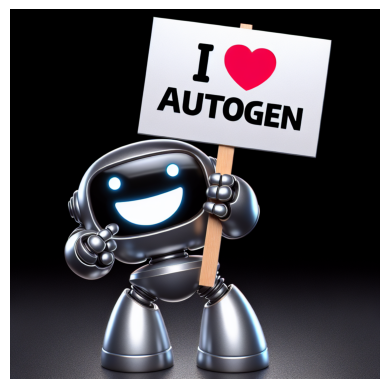

In [10]:
img = extract_img(dalle)

plt.imshow(img)
plt.axis("off")
plt.show()

Ten kod pobiera wygenerowany obraz z agenta `Dalle`, wyświetla go za pomocą biblioteki Matplotlib.

1.  **Pobieranie obrazu:**
    *   `img = extract_img(dalle)` wywołuje funkcję `extract_img` (zdefiniowaną wcześniej) i przekazuje jej agenta `Dalle`. Funkcja ta wyodrębnia dane obrazu z ostatniej wiadomości wysłanej przez agenta `Dalle` i konwertuje je do formatu PIL Image, który jest przypisywany do zmiennej `img`.

2.  **Wyświetlanie obrazu:**
    *   `plt.imshow(img)` używa funkcji `imshow` z biblioteki Matplotlib do wyświetlenia obrazu przechowywanego w zmiennej `img`.
    *   `plt.axis("off")` wyłącza wyświetlanie osi współrzędnych na wykresie, co sprawia, że obraz jest wyświetlany bez żadnych dodatkowych elementów graficznych.
    *   `plt.show()` wyświetla okno z wygenerowanym obrazem. Funkcja ta blokuje wykonanie programu do momentu zamknięcia okna z obrazem przez użytkownika.

Podsumowując, ten kod pobiera wygenerowany przez agenta `Dalle` obraz i prezentuje go wizualnie za pomocą biblioteki Matplotlib.

# Krytyka niepolityczna

In [11]:
class DalleCreator(AssistantAgent):
    def __init__(self, n_iters=2, **kwargs):
        """
        Initializes a DalleCreator instance.

        This agent facilitates the creation of visualizations through a collaborative effort among
        its child agents: dalle and critics.

        Parameters:
            - n_iters (int, optional): The number of "improvement" iterations to run. Defaults to 2.
            - **kwargs: keyword arguments for the parent AssistantAgent.
        """
        super().__init__(**kwargs)
        self.register_reply([Agent, None], reply_func=DalleCreator._reply_user, position=0)
        self._n_iters = n_iters

    def _reply_user(self, messages=None, sender=None, config=None):
        if all((messages is None, sender is None)):
            error_msg = f"Either {messages=} or {sender=} must be provided."
            logger.error(error_msg)  # noqa: F821
            raise AssertionError(error_msg)

        if messages is None:
            messages = self._oai_messages[sender]

        img_prompt = messages[-1]["content"]

        ## Define the agents
        self.critics = MultimodalConversableAgent(
            name="Critics",
            system_message="""You need to improve the prompt of the figures you saw.
How to create a figure that is better in terms of color, shape, text (clarity), and other things.
Reply with the following format:

CRITICS: the image needs to improve...
PROMPT: here is the updated prompt!

""",
            llm_config={"config_list": config_list_4v, "max_tokens": 1000},
            human_input_mode="NEVER",
            max_consecutive_auto_reply=3,
        )

        self.dalle = DALLEAgent(
            name="Dalle", llm_config={"config_list": config_list_dalle}, max_consecutive_auto_reply=0
        )

        # Data flow begins
        self.send(message=img_prompt, recipient=self.dalle, request_reply=True)
        img = extract_img(self.dalle)
        plt.imshow(img)
        plt.axis("off")  # Turn off axis numbers
        plt.show()
        print("Image PLOTTED")

        for i in range(self._n_iters):
            # Downsample the image s.t. GPT-4V can take
            img = extract_img(self.dalle)
            smaller_image = img.resize((128, 128), Image.Resampling.LANCZOS)
            smaller_image.save("result.png")

            self.msg_to_critics = f"""Here is the prompt: {img_prompt}.
            Here is the figure <img result.png>.
            Now, critic and create a prompt so that DALLE can give me a better image.
            Show me both "CRITICS" and "PROMPT"!
            """
            self.send(message=self.msg_to_critics, recipient=self.critics, request_reply=True)
            feedback = self._oai_messages[self.critics][-1]["content"]
            img_prompt = re.findall("PROMPT: (.*)", feedback)[0]

            self.send(message=img_prompt, recipient=self.dalle, request_reply=True)
            img = extract_img(self.dalle)
            plt.imshow(img)
            plt.axis("off")  # Turn off axis numbers
            plt.show()
            print(f"Image {i} PLOTTED")

        return True, "result.jpg"

Ten kod definiuje klasę `DalleCreator`, która jest podklasą `AssistantAgent` i służy do iteracyjnego tworzenia obrazów za pomocą DALL-E z wykorzystaniem agenta krytyka (critic) w celu poprawy jakości promptu.

Oto szczegółowe wyjaśnienie poszczególnych elementów klasy:

*   **`__init__(self, n_iters=2, **kwargs)`**: Konstruktor klasy.
    *   Przyjmuje liczbę iteracji ulepszania (`n_iters`, domyślnie 2) oraz dodatkowe argumenty słownikowe (`**kwargs`).
    *   Wywołuje konstruktor klasy bazowej `AssistantAgent` za pomocą `super().__init__(...)`.
    *   Rejestruje funkcję `DalleCreator._reply_user` jako handler odpowiedzi dla wiadomości od agentów typu `Agent` lub bez nadawcy (`None`), ustawiając jej priorytet na 0.
    *   Zapisuje liczbę iteracji ulepszania w atrybucie `self._n_iters`.

*   **`_reply_user(self, messages=None, sender=None, config=None)`**: Metoda obsługująca odpowiedzi od użytkownika lub innych agentów.
    *   Sprawdza, czy podano wiadomości (`messages`) lub nadawcę (`sender`). Jeśli nie, zgłasza błąd `AssertionError`.
    *   Jeśli `messages` jest puste, pobiera wiadomości z historii konwersacji dla danego nadawcy (`self._oai_messages[sender]`).
    *   Pobiera prompt obrazu z ostatniej wiadomości (`img_prompt = messages[-1]["content"]`).
    *   **Definiowanie agentów:** Tworzy instancje agenta krytyka (`self.critics`) i agenta Dalle (`self.dalle`).
        *   `self.critics`: Agent `MultimodalConversableAgent`, który ma za zadanie oceniać wygenerowane obrazy i proponować ulepszenia promptu. Konfiguracja zawiera model GPT-4V, maksymalną liczbę tokenów oraz ograniczenie liczby automatycznych odpowiedzi.
        *   `self.dalle`: Agent `DALLEAgent`, który generuje obrazy na podstawie podanego promptu.
    *   **Przepływ danych:** Rozpoczyna proces generowania i ulepszania obrazu:
        *   Wysyła początkowy prompt do agenta Dalle (`self.send(message=img_prompt, recipient=self.dalle, request_reply=True)`).
        *   Pobiera wygenerowany obraz za pomocą funkcji `extract_img` i wyświetla go za pomocą Matplotlib.
        *   Wykonuje iteracje ulepszania (`for i in range(self._n_iters):`). W każdej iteracji:
            *   Zmniejsza rozmiar obrazu do 128x128 pikseli, aby był kompatybilny z modelem GPT-4V.
            *   Zapisuje zmniejszony obraz jako "result.png".
            *   Tworzy wiadomość dla agenta krytyka zawierającą prompt i obraz oraz prośbę o ocenę i zaproponowanie ulepszonego promptu.
            *   Wysyła wiadomość do agenta krytyka (`self.send(message=self.msg_to_critics, recipient=self.critics, request_reply=True)`).
            *   Pobiera odpowiedź od agenta krytyka i wyodrębnia z niej ulepszony prompt za pomocą wyrażenia regularnego.
            *   Wysyła ulepszony prompt do agenta Dalle.
            *   Pobiera nowy obraz, wyświetla go i wypisuje informację o numerze iteracji.
    *   Zwraca `True` (co oznacza sukces) oraz nazwę pliku wynikowego ("result.jpg").

Podsumowując, klasa `DalleCreator` implementuje agenta, który iteracyjnie generuje obrazy za pomocą DALL-E i ulepsza je na podstawie opinii agenta krytyka. Proces ten pozwala na uzyskanie obrazów o wyższej jakości i bardziej zgodnych z oczekiwaniami użytkownika.

In [12]:
creator = DalleCreator(
    name="DALLECreator",
    max_consecutive_auto_reply=0,
    system_message="Help me coordinate generating image",
    llm_config=gpt4_llm_config,
)

user_proxy = UserProxyAgent(name="User", human_input_mode="NEVER", max_consecutive_auto_reply=0)


Ten kod tworzy dwie instancje agentów: `creator` (agent koordynujący generowanie obrazu za pomocą DALL-E) oraz `user_proxy` (agent reprezentujący użytkownika).

1.  **Tworzenie instancji agenta creator:**
    *   `creator = DalleCreator(name="DALLECreator", max_consecutive_auto_reply=0, system_message="Help me coordinate generating image", llm_config=gpt4_llm_config)` tworzy instancję klasy `DalleCreator`.
        *   `name="DALLECreator"` nadaje agentowi nazwę "DALLECreator".
        *   `max_consecutive_auto_reply=0` ogranicza liczbę automatycznych odpowiedzi agenta do 0, co oznacza, że odpowiada tylko raz na wiadomość.
        *   `system_message="Help me coordinate generating image"` ustawia wiadomość systemową definiującą rolę agenta jako koordynator generowania obrazu.
        *   `llm_config=gpt4_llm_config` przekazuje konfigurację modelu językowego GPT-4 zdefiniowaną wcześniej w zmiennej `gpt4_llm_config`.

2.  **Tworzenie instancji agenta user\_proxy:**
    *   `user_proxy = UserProxyAgent(name="User", human_input_mode="NEVER", max_consecutive_auto_reply=0)` tworzy instancję klasy `UserProxyAgent`, która symuluje interakcję z użytkownikiem.
        *   `name="User"` nadaje agentowi nazwę "User".
        *   `human_input_mode="NEVER"` wyłącza możliwość interakcji z użytkownikiem (agent nie będzie prosił o dane wejściowe od człowieka).
        *   `max_consecutive_auto_reply=0` ogranicza liczbę automatycznych odpowiedzi agenta do 0.

W efekcie tego kodu, tworzone są dwa agenty gotowe do interakcji: `creator`, który będzie generował i ulepszał obrazy za pomocą DALL-E oraz krytyka, oraz `user_proxy`, który w tym przypadku nie będzie wymagał interakcji z człowiekiem.

User (to DALLECreator):

Create an image with black background, a happy robot is showing a sign with "I Love AutoGen".

--------------------------------------------------------------------------------
DALLECreator (to Dalle):

Create an image with black background, a happy robot is showing a sign with "I Love AutoGen".

--------------------------------------------------------------------------------


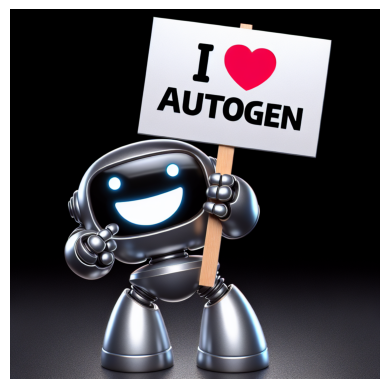

Image PLOTTED
DALLECreator (to Critics):

Here is the prompt: Create an image with black background, a happy robot is showing a sign with "I Love AutoGen"..
            Here is the figure <image>.
            Now, critic and create a prompt so that DALLE can give me a better image.
            Show me both "CRITICS" and "PROMPT"!
            

--------------------------------------------------------------------------------
Critics (to DALLECreator):

CRITICS: The image captures the essence of the prompt well, but there are areas where it can be enhanced. The robot's reflectivity and lighting feel a bit flat which minimizes depth and detail. The "I Love AutoGen" text on the sign could use a more vibrant color palette to make it pop against the black background. Additionally, the overall composition could be more dynamic if the robot had a more elaborate pose.

PROMPT: Create an image with a deep black background. Feature a glossy, metallic robot with dynamic, expressive posture, beaming

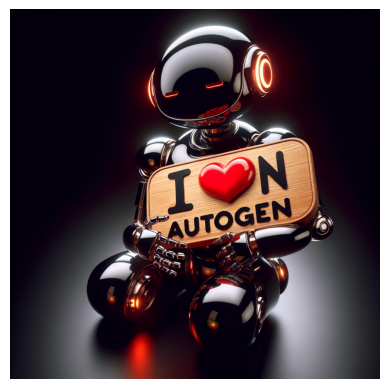

Image 0 PLOTTED
DALLECreator (to Critics):

Here is the prompt: Create an image with a deep black background. Feature a glossy, metallic robot with dynamic, expressive posture, beaming cheerfully. The robot holds a wooden sign that says "I Love AutoGen", with the text in bright red and heart shape in true red, ensuring high contrast and visibility. Enhance the lighting to create reflections on the robot that suggest depth and three-dimensionality. Include subtle glows around the edges of the robot to highlight its contours against the dark background..
            Here is the figure <image>.
            Now, critic and create a prompt so that DALLE can give me a better image.
            Show me both "CRITICS" and "PROMPT"!
            

--------------------------------------------------------------------------------
Critics (to DALLECreator):

CRITICS: The revised image shows significant improvements, particularly in the dynamic pose and the glow effect, enhancing the robot's three-di

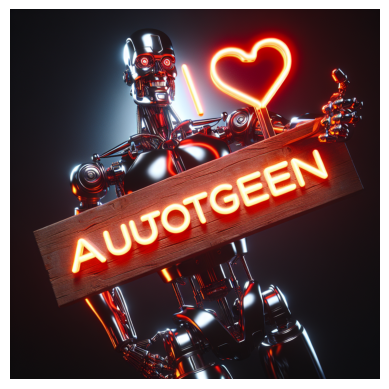

Image 1 PLOTTED
DALLECreator (to User):

result.jpg

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (1e7f5b28-611f-4dd7-8b81-c32442064d22): Maximum number of consecutive auto-replies reached


ChatResult(chat_id=None, chat_history=[{'content': 'Create an image with black background, a happy robot is showing a sign with "I Love AutoGen".', 'role': 'assistant', 'name': 'User'}, {'content': 'result.jpg', 'role': 'user', 'name': 'DALLECreator'}], summary='result.jpg', cost={'usage_including_cached_inference': {'total_cost': 0}, 'usage_excluding_cached_inference': {'total_cost': 0}}, human_input=[])

In [13]:

user_proxy.initiate_chat(
    creator, message="""Create an image with black background, a happy robot is showing a sign with "I Love AutoGen"."""
)

Ten kod inicjuje konwersację między agentem `user_proxy` a agentem `creator`.

*   `user_proxy.initiate_chat(creator, message="""Create an image with black background, a happy robot is showing a sign with "I Love AutoGen".""")` wywołuje metodę `initiate_chat` na obiekcie `user_proxy`, rozpoczynając interakcję z agentem `creator`.
    *   `creator` określa odbiorcę wiadomości (agent creator).
    *   `message="""Create an image with black background, a happy robot is showing a sign with "I Love AutoGen"."""` to treść wiadomości wysyłanej do agenta creator. Jest to prompt opisujący obraz, który ma zostać wygenerowany.

W efekcie tego kodu, agent `user_proxy` wysyła polecenie do agenta `creator`, aby wygenerował obraz przedstawiający szczęśliwego robota z napisem "I Love AutoGen" na czarnym tle. Agent `creator` przetworzy to polecenie, wykorzystując agenta Dalle i krytyka do iteracyjnego generowania i ulepszania obrazu zgodnie z logiką zdefiniowaną w klasie `DalleCreator`.